# Book Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder

In [12]:
# Import Dataset
data = pd.read_csv(r'E:\Assignment\Assignment 9 - Association rule\book.csv')
data

,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence
0,0,1,0,1,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,1,0,1,0,0,0,0
4,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,1,0,0,1,1,1,0,1,1
1996,0,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,0
1998,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Data preprocessing not required as it is already in transaction format

# Apriori Algorithm

1. Association rules with 20% Support and 50% confidence

In [27]:
# With 20% Support
frequent_itemsets=apriori(data,min_support=0.2,use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.4230,(ChildBks)
1,0.2475,(YouthBks)
2,0.4310,(CookBks)
3,0.2820,(DoItYBks)
4,0.2145,(RefBks)
5,0.2410,(ArtBks)
6,0.2760,(GeogBks)
7,0.2560,"(ChildBks, CookBks)"


In [28]:
# with 50% confidence
rules=association_rules(frequent_itemsets,metric='lift',min_threshold=0.5)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(CookBks),0.423,0.431,0.256,0.605201,1.404179,0.073687,1.441240
1,(CookBks),(ChildBks),0.431,0.423,0.256,0.593968,1.404179,0.073687,1.421069


In [29]:
# An leverage value of 0 indicates independence. Range will be [-1 1]
# A high conviction value means that the consequent is highly depending on the antecedent and range [0 inf]

In [31]:

# Lift Ratio > 1 is a good influential rule in selecting the associated transactions
rules[rules.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(CookBks),0.423,0.431,0.256,0.605201,1.404179,0.073687,1.441240
1,(CookBks),(ChildBks),0.431,0.423,0.256,0.593968,1.404179,0.073687,1.421069


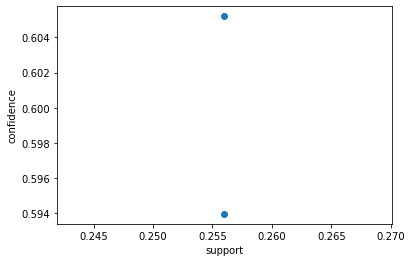

In [32]:

# visualization of obtained rule
plt.scatter(rules['support'],rules['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()

2. Association rules with 10% Support and 80% confidence

In [18]:
# With 10% Support
frequent_itemsets2=apriori(data,min_support=0.1,use_colnames=True)
frequent_itemsets2

,support,itemsets
0,0.4230,(ChildBks)
1,0.2475,(YouthBks)
2,0.4310,(CookBks)
3,0.2820,(DoItYBks)
4,0.2145,(RefBks)
5,0.2410,(ArtBks)
6,0.2760,(GeogBks)
7,0.1135,(ItalCook)
8,0.1085,(Florence)
9,0.1650,"(ChildBks, YouthBks)"


In [19]:

# With 80% confidence
rules2=association_rules(frequent_itemsets2,metric='lift',min_threshold=0.8)
rules2

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(YouthBks),0.4230,0.2475,0.1650,0.390071,1.576044,0.060308,1.233750
1,(YouthBks),(ChildBks),0.2475,0.4230,0.1650,0.666667,1.576044,0.060308,1.731000
2,(ChildBks),(CookBks),0.4230,0.4310,0.2560,0.605201,1.404179,0.073687,1.441240
3,(CookBks),(ChildBks),0.4310,0.4230,0.2560,0.593968,1.404179,0.073687,1.421069
4,(ChildBks),(DoItYBks),0.4230,0.2820,0.1840,0.434988,1.542511,0.064714,1.270770
...,...,...,...,...,...,...,...,...,...
95,"(ArtBks, CookBks)",(GeogBks),0.1670,0.2760,0.1035,0.619760,2.245509,0.057408,1.904063
96,"(CookBks, GeogBks)",(ArtBks),0.1925,0.2410,0.1035,0.537662,2.230964,0.057107,1.641657
97,(ArtBks),"(CookBks, GeogBks)",0.2410,0.1925,0.1035,0.429461,2.230964,0.057107,1.415327
98,(GeogBks),"(ArtBks, CookBks)",0.2760,0.1670,0.1035,0.375000,2.245509,0.057408,1.332800


In [20]:
rules2[rules.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(YouthBks),0.4230,0.2475,0.1650,0.390071,1.576044,0.060308,1.233750
1,(YouthBks),(ChildBks),0.2475,0.4230,0.1650,0.666667,1.576044,0.060308,1.731000
2,(ChildBks),(CookBks),0.4230,0.4310,0.2560,0.605201,1.404179,0.073687,1.441240
3,(CookBks),(ChildBks),0.4310,0.4230,0.2560,0.593968,1.404179,0.073687,1.421069
4,(ChildBks),(DoItYBks),0.4230,0.2820,0.1840,0.434988,1.542511,0.064714,1.270770
...,...,...,...,...,...,...,...,...,...
95,"(ArtBks, CookBks)",(GeogBks),0.1670,0.2760,0.1035,0.619760,2.245509,0.057408,1.904063
96,"(CookBks, GeogBks)",(ArtBks),0.1925,0.2410,0.1035,0.537662,2.230964,0.057107,1.641657
97,(ArtBks),"(CookBks, GeogBks)",0.2410,0.1925,0.1035,0.429461,2.230964,0.057107,1.415327
98,(GeogBks),"(ArtBks, CookBks)",0.2760,0.1670,0.1035,0.375000,2.245509,0.057408,1.332800


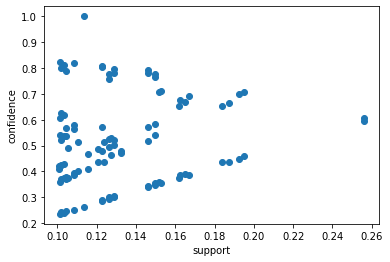

In [21]:
plt.scatter(rules2['support'],rules2['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()

3. Association rules with 8% Support and 70% confidence

In [34]:
# With 8% Support
frequent_itemsets3=apriori(data,min_support=0.08,use_colnames=True)
frequent_itemsets3

,support,itemsets
0,0.4230,(ChildBks)
1,0.2475,(YouthBks)
2,0.4310,(CookBks)
3,0.2820,(DoItYBks)
4,0.2145,(RefBks)
5,0.2410,(ArtBks)
6,0.2760,(GeogBks)
7,0.1135,(ItalCook)
8,0.1085,(Florence)
9,0.1650,"(ChildBks, YouthBks)"


In [35]:
# With 70% confidence
rules3=association_rules(frequent_itemsets3,metric='lift',min_threshold=0.7)
rules3

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(YouthBks),0.4230,0.2475,0.1650,0.390071,1.576044,0.060308,1.233750
1,(YouthBks),(ChildBks),0.2475,0.4230,0.1650,0.666667,1.576044,0.060308,1.731000
2,(ChildBks),(CookBks),0.4230,0.4310,0.2560,0.605201,1.404179,0.073687,1.441240
3,(CookBks),(ChildBks),0.4310,0.4230,0.2560,0.593968,1.404179,0.073687,1.421069
4,(ChildBks),(DoItYBks),0.4230,0.2820,0.1840,0.434988,1.542511,0.064714,1.270770
...,...,...,...,...,...,...,...,...,...
249,"(CookBks, GeogBks)","(ArtBks, ChildBks)",0.1925,0.1625,0.0835,0.433766,2.669331,0.052219,1.479071
250,(ArtBks),"(ChildBks, CookBks, GeogBks)",0.2410,0.1495,0.0835,0.346473,2.317545,0.047471,1.301400
251,(ChildBks),"(ArtBks, CookBks, GeogBks)",0.4230,0.1035,0.0835,0.197400,1.907242,0.039720,1.116994
252,(GeogBks),"(ArtBks, ChildBks, CookBks)",0.2760,0.1265,0.0835,0.302536,2.391591,0.048586,1.252395


In [36]:
rules3[rules3.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ChildBks),(YouthBks),0.4230,0.2475,0.1650,0.390071,1.576044,0.060308,1.233750
1,(YouthBks),(ChildBks),0.2475,0.4230,0.1650,0.666667,1.576044,0.060308,1.731000
2,(ChildBks),(CookBks),0.4230,0.4310,0.2560,0.605201,1.404179,0.073687,1.441240
3,(CookBks),(ChildBks),0.4310,0.4230,0.2560,0.593968,1.404179,0.073687,1.421069
4,(ChildBks),(DoItYBks),0.4230,0.2820,0.1840,0.434988,1.542511,0.064714,1.270770
...,...,...,...,...,...,...,...,...,...
249,"(CookBks, GeogBks)","(ArtBks, ChildBks)",0.1925,0.1625,0.0835,0.433766,2.669331,0.052219,1.479071
250,(ArtBks),"(ChildBks, CookBks, GeogBks)",0.2410,0.1495,0.0835,0.346473,2.317545,0.047471,1.301400
251,(ChildBks),"(ArtBks, CookBks, GeogBks)",0.4230,0.1035,0.0835,0.197400,1.907242,0.039720,1.116994
252,(GeogBks),"(ArtBks, ChildBks, CookBks)",0.2760,0.1265,0.0835,0.302536,2.391591,0.048586,1.252395


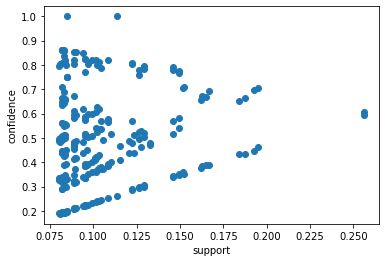

In [37]:
# visualization of obtained rule
plt.scatter(rules3['support'],rules3['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()

# My_Movies

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder

In [2]:
# Import Dataset
data = pd.read_csv(r'E:\Assignment\Assignment 9 - Association rule\my_movies.csv')
data.head()

,V1,V2,V3,V4,V5,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile
0,Sixth Sense,LOTR1,Harry Potter1,Green Mile,LOTR2,1,0,1,1,0,1,0,0,0,1
1,Gladiator,Patriot,Braveheart,NaN,NaN,0,1,0,0,1,0,0,0,1,0
2,LOTR1,LOTR2,NaN,NaN,NaN,0,0,1,0,0,1,0,0,0,0
3,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0
4,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0


Pre-Processing

In [3]:
data1=pd.get_dummies(data)
data1

,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile,...,V2_LOTR,V2_LOTR1,V2_LOTR2,V2_Patriot,V3_Braveheart,V3_Gladiator,V3_Harry Potter1,V3_Sixth Sense,V4_Green Mile,V5_LOTR2
0,1,0,1,1,0,1,0,0,0,1,...,0,1,0,0,0,0,1,0,1,1
1,0,1,0,0,1,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
2,0,0,1,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,1,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,1,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
6,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
8,1,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
9,1,1,0,0,0,0,0,1,0,1,...,1,0,0,0,0,1,0,0,1,0


1. Association rules with 10% Support and 70% confidence

In [4]:
# With 10% Support
frequent_itemsets=apriori(data1,min_support=0.1,use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.6,(Sixth Sense)
1,0.7,(Gladiator)
2,0.2,(LOTR1)
3,0.2,(Harry Potter1)
4,0.6,(Patriot)
...,...,...
1392,0.1,"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V..."
1393,0.1,"(Sixth Sense, V1_Sixth Sense, V2_LOTR1, V4_Gre..."
1394,0.1,"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V..."
1395,0.1,"(Harry Potter1, V1_Sixth Sense, V2_LOTR1, V4_G..."


In [5]:
# with 70% confidence
rules=association_rules(frequent_itemsets,metric='lift',min_threshold=0.7)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.80
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.40
2,(Sixth Sense),(LOTR1),0.6,0.2,0.1,0.166667,0.833333,-0.02,0.96
3,(LOTR1),(Sixth Sense),0.2,0.6,0.1,0.500000,0.833333,-0.02,0.80
4,(Sixth Sense),(Harry Potter1),0.6,0.2,0.1,0.166667,0.833333,-0.02,0.96
...,...,...,...,...,...,...,...,...,...
64247,(V3_Harry Potter1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64248,(LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80
64249,(V5_LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64250,(LOTR1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80


In [6]:
rules.sort_values('lift',ascending=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
1611,"(Sixth Sense, V1_Sixth Sense, Green Mile)",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000
3623,(Gladiator),"(V4_Green Mile, V1_Sixth Sense, Green Mile)",0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
57,(V4_Green Mile),(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000
56,(Gladiator),(V4_Green Mile),0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
227,"(Sixth Sense, V1_Sixth Sense)",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000
...,...,...,...,...,...,...,...,...,...
29720,"(Harry Potter1, V2_LOTR1, V3_Harry Potter1)","(V5_LOTR2, V4_Green Mile, Green Mile)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
29721,"(V5_LOTR2, Harry Potter1, V2_LOTR1)","(Green Mile, V4_Green Mile, V3_Harry Potter1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
29722,"(Harry Potter1, V2_LOTR1, Green Mile)","(V5_LOTR2, V4_Green Mile, V3_Harry Potter1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
29724,"(V5_LOTR2, Harry Potter1, V4_Green Mile)","(Green Mile, V2_LOTR1, V3_Harry Potter1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf


In [7]:
# Lift Ratio > 1 is a good influential rule in selecting the associated transactions
rules[rules.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.80
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.40
6,(Sixth Sense),(Patriot),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
7,(Patriot),(Sixth Sense),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
10,(Sixth Sense),(LOTR),0.6,0.1,0.1,0.166667,1.666667,0.04,1.08
...,...,...,...,...,...,...,...,...,...
64247,(V3_Harry Potter1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64248,(LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80
64249,(V5_LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64250,(LOTR1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80


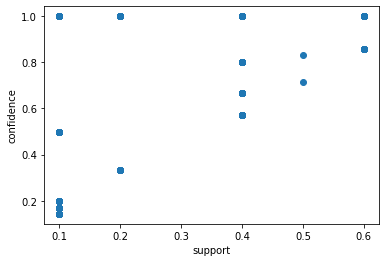

In [8]:
# visualization of obtained rule
plt.scatter(rules['support'],rules['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()

2. Association rules with 20% Support and 60% confidence

In [9]:
# With 20% Support
frequent_itemsets2=apriori(data1,min_support=0.20,use_colnames=True)
frequent_itemsets2

,support,itemsets
0,0.6,(Sixth Sense)
1,0.7,(Gladiator)
2,0.2,(LOTR1)
3,0.2,(Harry Potter1)
4,0.6,(Patriot)
...,...,...
76,0.4,"(Sixth Sense, V2_Patriot, Patriot, V3_Sixth Se..."
77,0.4,"(Sixth Sense, V2_Patriot, V3_Sixth Sense, Glad..."
78,0.4,"(Sixth Sense, V2_Patriot, Patriot, V3_Sixth Se..."
79,0.4,"(V2_Patriot, Patriot, V3_Sixth Sense, Gladiato..."


In [10]:
# With 60% confidence
rules2=association_rules(frequent_itemsets2,metric='lift',min_threshold=0.6)
rules2

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.8
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.4
2,(Sixth Sense),(Patriot),0.6,0.6,0.4,0.666667,1.111111,0.04,1.2
3,(Patriot),(Sixth Sense),0.6,0.6,0.4,0.666667,1.111111,0.04,1.2
4,(Sixth Sense),(Green Mile),0.6,0.2,0.2,0.333333,1.666667,0.08,1.2
...,...,...,...,...,...,...,...,...,...
649,(V2_Patriot),"(Sixth Sense, Patriot, V3_Sixth Sense, Gladiat...",0.6,0.4,0.4,0.666667,1.666667,0.16,1.8
650,(Patriot),"(Sixth Sense, V2_Patriot, V3_Sixth Sense, Glad...",0.6,0.4,0.4,0.666667,1.666667,0.16,1.8
651,(V3_Sixth Sense),"(Sixth Sense, V2_Patriot, Patriot, Gladiator, ...",0.4,0.4,0.4,1.000000,2.500000,0.24,inf
652,(Gladiator),"(Sixth Sense, V2_Patriot, Patriot, V3_Sixth Se...",0.7,0.4,0.4,0.571429,1.428571,0.12,1.4


In [11]:
rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
32126,"(Sixth Sense, LOTR2, V5_LOTR2, LOTR1)","(Green Mile, Harry Potter1, V3_Harry Potter1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33436,"(LOTR2, V4_Green Mile, V5_LOTR2)","(Sixth Sense, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33414,"(Sixth Sense, LOTR2, V4_Green Mile)","(V5_LOTR2, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33415,"(Sixth Sense, V4_Green Mile, V5_LOTR2)","(LOTR2, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33416,"(Sixth Sense, V4_Green Mile, LOTR1)","(LOTR2, Harry Potter1, V2_LOTR1, V5_LOTR2)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
...,...,...,...,...,...,...,...,...,...
1622,(Gladiator),"(Sixth Sense, V1_Sixth Sense, Green Mile)",0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
56,(Gladiator),(V4_Green Mile),0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
6290,"(Sixth Sense, V1_Sixth Sense, V4_Green Mile, G...",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000
227,"(Sixth Sense, V1_Sixth Sense)",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000


In [12]:
rules[rules.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.80
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.40
6,(Sixth Sense),(Patriot),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
7,(Patriot),(Sixth Sense),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
10,(Sixth Sense),(LOTR),0.6,0.1,0.1,0.166667,1.666667,0.04,1.08
...,...,...,...,...,...,...,...,...,...
64247,(V3_Harry Potter1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64248,(LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80
64249,(V5_LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64250,(LOTR1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80


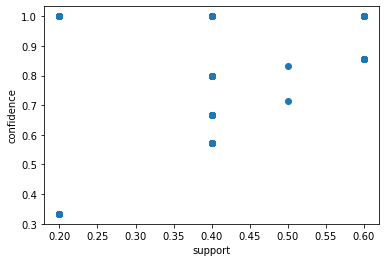

In [13]:
# visualization of obtained rule
plt.scatter(rules2['support'],rules2['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()

3. Association rules with 5% Support and 80% confidence

In [14]:
# With 5% Support
frequent_itemsets3=apriori(data1,min_support=0.05,use_colnames=True)
frequent_itemsets3

,support,itemsets
0,0.6,(Sixth Sense)
1,0.7,(Gladiator)
2,0.2,(LOTR1)
3,0.2,(Harry Potter1)
4,0.6,(Patriot)
...,...,...
1392,0.1,"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V..."
1393,0.1,"(Sixth Sense, V1_Sixth Sense, V2_LOTR1, V4_Gre..."
1394,0.1,"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V..."
1395,0.1,"(Harry Potter1, V1_Sixth Sense, V2_LOTR1, V4_G..."


In [15]:
# With 80% confidence
rules3=association_rules(frequent_itemsets3,metric='lift',min_threshold=0.8)
rules3

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.80
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.40
2,(Sixth Sense),(LOTR1),0.6,0.2,0.1,0.166667,0.833333,-0.02,0.96
3,(LOTR1),(Sixth Sense),0.2,0.6,0.1,0.500000,0.833333,-0.02,0.80
4,(Sixth Sense),(Harry Potter1),0.6,0.2,0.1,0.166667,0.833333,-0.02,0.96
...,...,...,...,...,...,...,...,...,...
64219,(V3_Harry Potter1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64220,(LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80
64221,(V5_LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64222,(LOTR1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80


In [16]:
rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
32126,"(Sixth Sense, LOTR2, V5_LOTR2, LOTR1)","(Green Mile, Harry Potter1, V3_Harry Potter1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33436,"(LOTR2, V4_Green Mile, V5_LOTR2)","(Sixth Sense, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33414,"(Sixth Sense, LOTR2, V4_Green Mile)","(V5_LOTR2, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33415,"(Sixth Sense, V4_Green Mile, V5_LOTR2)","(LOTR2, Harry Potter1, V2_LOTR1, LOTR1)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
33416,"(Sixth Sense, V4_Green Mile, LOTR1)","(LOTR2, Harry Potter1, V2_LOTR1, V5_LOTR2)",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
...,...,...,...,...,...,...,...,...,...
1622,(Gladiator),"(Sixth Sense, V1_Sixth Sense, Green Mile)",0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
56,(Gladiator),(V4_Green Mile),0.7,0.2,0.1,0.142857,0.714286,-0.04,0.933333
6290,"(Sixth Sense, V1_Sixth Sense, V4_Green Mile, G...",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000
227,"(Sixth Sense, V1_Sixth Sense)",(Gladiator),0.2,0.7,0.1,0.500000,0.714286,-0.04,0.600000


In [17]:
rules3[rules3.lift>1]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Sixth Sense),(Gladiator),0.6,0.7,0.5,0.833333,1.190476,0.08,1.80
1,(Gladiator),(Sixth Sense),0.7,0.6,0.5,0.714286,1.190476,0.08,1.40
6,(Sixth Sense),(Patriot),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
7,(Patriot),(Sixth Sense),0.6,0.6,0.4,0.666667,1.111111,0.04,1.20
10,(Sixth Sense),(LOTR),0.6,0.1,0.1,0.166667,1.666667,0.04,1.08
...,...,...,...,...,...,...,...,...,...
64219,(V3_Harry Potter1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64220,(LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80
64221,(V5_LOTR2),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.1,0.1,0.1,1.000000,10.000000,0.09,inf
64222,(LOTR1),"(Sixth Sense, Harry Potter1, V1_Sixth Sense, V...",0.2,0.1,0.1,0.500000,5.000000,0.08,1.80


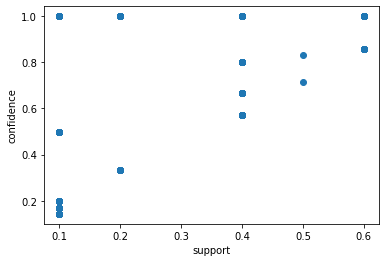

In [18]:
# visualization of obtained rule
plt.scatter(rules3['support'],rules3['confidence'])
plt.xlabel('support')
plt.ylabel('confidence') 
plt.show()